In [22]:
import pandas as pd
import yaml
import networkx as nx
import matplotlib.pyplot as plt
import os

In [26]:
users = pd.read_csv("/home/khosilbek/Programming/Python/Itransition/Task4/data/DATA1/users.csv")
orders = pd.read_parquet("/home/khosilbek/Programming/Python/Itransition/Task4/data/DATA1/orders.parquet", engine='fastparquet')
with open("/home/khosilbek/Programming/Python/Itransition/Task4/data/DATA1/books.yaml", 'r') as f:
    books_list = yaml.safe_load(f)
books = pd.DataFrame([dict(zip([k.lstrip(':') for k in b.keys()], b.values())) for b in books_list])

In [27]:
users

,id,name,address,phone,email
0,44533,Hoyt Carter,"Apt. 300 8604 Ashlyn Wells, Effertzstad, ID 02997",(462) 385-4294,mckinley.rowe@harber.example
1,46128,Marco Kulas,"Apt. 538 816 Bechtelar Ferry, Lincolnhaven, KS...",913.466.4487,francisco@murray-cronin.test
2,46407,Denny Goyette LLD,"Apt. 174 39450 Mohr Rapids, Port Neomistad, AL...",(801) 970-3335,marguerita@wuckert.test
3,44602,Zackary Heller,"Apt. 608 74228 Bogan Valley, South Stepanieshi...",895.829.5417,annabelle@hessel.test
4,45828,Jess Beier,"2716 Jacobi Path, Ziemanntown, SC 65624-4660",(113) 784-3410,minh@hettinger.example
...,...,...,...,...,...
3288,45131,Dr. Dulce Welch,"7640 Reichel Island, Swaniawskichester, VA 384...",397-216-6952,deetta_hilll@schaden.test
3289,44840,Ted Aufderhar Esq.,NaN,424 718 8383,shella.pouros@murazik.example
3290,45538,Irmgard Erdman,NaN,178.866.0267,dana@leuschke.example
3291,45097,Makeda Schmeler Ret.,"Suite 412 6556 Arnold Turnpike, Cummerataview,...",784.918.2549,daren_haag@kling.example


In [29]:
orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping
0,71389,47288,18976,2,27.00$,10/01/24 10:38:08 A.M.,None
1,66343,47049,19403,1,€50¢50,10:14;19-Oct-2024,"4940 Arnoldo Keys, West Arnette, KS 77599"
2,72606,46685,19500,1,USD 45.99,"22:13:35,2025-07-02",
3,68462,45336,18992,1,€ 71.00,2025-10-20 16:25:20,
4,72691,45311,19388,1,52.25 $,"08:48:47 A.M.,28-August-2024",None
...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,57.99 EUR,04:51:02;04/06/25,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2..."
11233,72164,46481,18864,2,$71¢00,12:38:25 A.M. 2024-06-20,NULL
11234,70697,44686,19083,5,€50.,"11-Dec-2024, 14:52",NULL
11235,64646,46203,19190,1,44.75USD,11:09;05/17/25,


In [30]:
orders["timestamp"][:5]

0          10/01/24 10:38:08 A.M.
1               10:14;19-Oct-2024
2             22:13:35,2025-07-02
3             2025-10-20 16:25:20
4    08:48:47 A.M.,28-August-2024
Name: timestamp, dtype: object

In [33]:
import re


def format_cleaner(text):
    if not isinstance(text, str): return text

    text = text.replace('"', '').strip()

    text = text.replace(';', ' ').replace(',', ' ').replace('A.M.', 'AM').replace('P.M.', 'PM')

    text = re.sub(r'\s+', ' ', text)

    return text

df = pd.DataFrame({'raw_timestamp': orders["timestamp"]})

df['cleaned'] = df['raw_timestamp'].apply(format_cleaner)

df['final_datetime'] = pd.to_datetime(df['cleaned'], errors='coerce')

print(df[['raw_timestamp', 'final_datetime']])

/tmp/ipykernel_8600/1698128739.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['final_datetime'] = pd.to_datetime(df['cleaned'], errors='coerce')


                      raw_timestamp      final_datetime
0            10/01/24 10:38:08 A.M. 2024-10-01 10:38:08
1                 10:14;19-Oct-2024 2024-10-19 10:14:00
2               22:13:35,2025-07-02 2025-07-02 22:13:35
3               2025-10-20 16:25:20 2025-10-20 16:25:20
4      08:48:47 A.M.,28-August-2024 2024-08-28 08:48:47
...                             ...                 ...
11232             04:51:02;04/06/25 2025-04-06 04:51:02
11233      12:38:25 A.M. 2024-06-20 2024-06-20 00:38:25
11234            11-Dec-2024, 14:52 2024-12-11 14:52:00
11235                11:09;05/17/25 2025-05-17 11:09:00
11236          07:54:28 pm 09/25/24 2024-09-25 19:54:28

[11237 rows x 2 columns]


In [34]:
import re

def format_cleaner(text):
    if not isinstance(text, str): return text
    text = text.replace('"', '').strip()
    text = text.replace(';', ' ').replace(',', ' ').replace('A.M.', 'AM').replace('P.M.', 'PM')
    text = re.sub(r'\s+', ' ', text)
    return text

orders['cleaned_ts'] = orders['timestamp'].apply(format_cleaner)

orders['timestamp'] = pd.to_datetime(orders['cleaned_ts'], errors='coerce')

orders = orders.drop(columns=['cleaned_ts'])

orders['date'] = orders['timestamp'].dt.strftime('%Y-%m-%d')

print(orders[['timestamp', 'date']].head())

            timestamp        date
0 2024-10-01 10:38:08  2024-10-01
1 2024-10-19 10:14:00  2024-10-19
2 2025-07-02 22:13:35  2025-07-02
3 2025-10-20 16:25:20  2025-10-20
4 2024-08-28 08:48:47  2024-08-28


/tmp/ipykernel_8600/746293132.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders['timestamp'] = pd.to_datetime(orders['cleaned_ts'], errors='coerce')


In [35]:
orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,date
0,71389,47288,18976,2,27.00$,2024-10-01 10:38:08,None,2024-10-01
1,66343,47049,19403,1,€50¢50,2024-10-19 10:14:00,"4940 Arnoldo Keys, West Arnette, KS 77599",2024-10-19
2,72606,46685,19500,1,USD 45.99,2025-07-02 22:13:35,,2025-07-02
3,68462,45336,18992,1,€ 71.00,2025-10-20 16:25:20,,2025-10-20
4,72691,45311,19388,1,52.25 $,2024-08-28 08:48:47,None,2024-08-28
...,...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,57.99 EUR,2025-04-06 04:51:02,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2...",2025-04-06
11233,72164,46481,18864,2,$71¢00,2024-06-20 00:38:25,NULL,2024-06-20
11234,70697,44686,19083,5,€50.,2024-12-11 14:52:00,NULL,2024-12-11
11235,64646,46203,19190,1,44.75USD,2025-05-17 11:09:00,,2025-05-17


In [36]:
def clean_price(price_str):
    if not isinstance(price_str, str):
        return float(price_str)

    text = price_str.upper()

    text = re.sub(r'(\d+)\$(\d+)', r'\1.\2', text)

    text = re.sub(r'[^0-9.]', '', text)

    try:
        price = float(text)
    except ValueError:
        price = 0.0

    final_price = price * 1.2

    return round(final_price, 2)

orders['unit_price'] = orders['unit_price'].apply(clean_price)

In [37]:
orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,date
0,71389,47288,18976,2,32.40,2024-10-01 10:38:08,None,2024-10-01
1,66343,47049,19403,1,6060.00,2024-10-19 10:14:00,"4940 Arnoldo Keys, West Arnette, KS 77599",2024-10-19
2,72606,46685,19500,1,55.19,2025-07-02 22:13:35,,2025-07-02
3,68462,45336,18992,1,85.20,2025-10-20 16:25:20,,2025-10-20
4,72691,45311,19388,1,62.70,2024-08-28 08:48:47,None,2024-08-28
...,...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,69.59,2025-04-06 04:51:02,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2...",2025-04-06
11233,72164,46481,18864,2,8520.00,2024-06-20 00:38:25,NULL,2024-06-20
11234,70697,44686,19083,5,60.00,2024-12-11 14:52:00,NULL,2024-12-11
11235,64646,46203,19190,1,53.70,2025-05-17 11:09:00,,2025-05-17


In [38]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 11237 entries, 0 to 11236
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          11237 non-null  int64         
 1   user_id     11237 non-null  int64         
 2   book_id     11237 non-null  int64         
 3   quantity    11237 non-null  int32         
 4   unit_price  11237 non-null  float64       
 5   timestamp   11237 non-null  datetime64[us]
 6   shipping    8427 non-null   object        
 7   date        11237 non-null  str           
dtypes: datetime64[us](1), float64(1), int32(1), int64(3), object(1), str(1)
memory usage: 658.5+ KB


In [39]:
orders['paid_price'] = orders['quantity'] * orders['unit_price']

In [40]:
orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,date,paid_price
0,71389,47288,18976,2,32.40,2024-10-01 10:38:08,None,2024-10-01,64.80
1,66343,47049,19403,1,6060.00,2024-10-19 10:14:00,"4940 Arnoldo Keys, West Arnette, KS 77599",2024-10-19,6060.00
2,72606,46685,19500,1,55.19,2025-07-02 22:13:35,,2025-07-02,55.19
3,68462,45336,18992,1,85.20,2025-10-20 16:25:20,,2025-10-20,85.20
4,72691,45311,19388,1,62.70,2024-08-28 08:48:47,None,2024-08-28,62.70
...,...,...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,69.59,2025-04-06 04:51:02,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2...",2025-04-06,69.59
11233,72164,46481,18864,2,8520.00,2024-06-20 00:38:25,NULL,2024-06-20,17040.00
11234,70697,44686,19083,5,60.00,2024-12-11 14:52:00,NULL,2024-12-11,300.00
11235,64646,46203,19190,1,53.70,2025-05-17 11:09:00,,2025-05-17,53.70


In [49]:
orders = orders.drop_duplicates().dropna()
users = users.fillna('')

In [50]:
daily_revenue = orders.groupby('date')['paid_price'].sum().sort_values(ascending=False)
print("Top 5 kun (daromad bo'yicha):")
print(daily_revenue.head(5))

Top 5 kun (daromad bo'yicha):
date
2025-02-10    70226.01
2025-03-29    65519.37
2024-09-06    60332.36
2024-12-05    56876.68
2024-07-13    56099.33
Name: paid_price, dtype: float64


In [51]:
G = nx.Graph()
for i, row in users.iterrows():
    G.add_node(row['id'])

user_list = users.to_dict('records')
for i in range(len(user_list)):
    for j in range(i + 1, len(user_list)):
        u1, u2 = user_list[i], user_list[j]
        matches = sum([
            u1['name'] == u2['name'],
            u1['address'] == u2['address'],
            u1['phone'] == u2['phone'],
            u1['email'] == u2['email']
        ])
        if matches >= 3:
            G.add_edge(u1['id'], u2['id'])

unique_user_groups = list(nx.connected_components(G))
print(f"Haqiqiy noyob foydalanuvchilar soni: {len(unique_user_groups)}")

Haqiqiy noyob foydalanuvchilar soni: 3115


In [52]:
books

,id,title,author,genre,publisher,year,author_set
0,19199,The Yellow Meads of Asphodel,Carolyne West,Classic,Mainstream Publishing,2009,"(Carolyne West,)"
1,19398,From Here to Eternity,"Rep. Heath Stiedemann, Gino Welch, Haydee Larson",Short story,Vintage Books,2001,"(Gino Welch, Haydee Larson, Rep. Heath Stiedem..."
2,19483,Eyeless in Gaza,Vannessa Price,Biography/Autobiography,Pavilion Books,1886,"(Vannessa Price,)"
3,19506,Precious Bane,Miss Yong Wyman,Realistic fiction,New English Library,2021,"(Miss Yong Wyman,)"
4,19570,City of God,Travis Moore,Suspense/Thriller,Bellevue Literary Press,1847,"(Travis Moore,)"
...,...,...,...,...,...,...,...
748,19246,Eternal Sunshine of the Spotless Mind,Carisa Blick,Realistic fiction,Victor Gollancz Ltd,2020,"(Carisa Blick,)"
749,19452,Command & Conquer: Tiberium Alliances,"Numbers Howell DDS, Tyson Treutel",Mythopoeia,Shire Books,1986,"(Numbers Howell DDS, Tyson Treutel)"
750,18843,Ice Climbers,"Jenice Bartell, Raye Watsica",Humor,NULL,1990,"(Jenice Bartell, Raye Watsica)"
751,19494,Mad Max: Fury Road,Blythe Bernhard,Speech,Packt Publishing,2005,"(Blythe Bernhard,)"


In [53]:
books['author_set'] = books['author'].apply(lambda x: tuple(sorted([a.strip() for a in x.split(',')])))
unique_author_sets = books['author_set'].nunique()
print(f"Noyob mualliflar to'plami soni: {unique_author_sets}")

Noyob mualliflar to'plami soni: 325


In [54]:
order_items = orders.merge(books, left_on='book_id', right_on='id')
popular_author = order_items.groupby('author')['quantity'].sum().idxmax()
print(f"Eng mashhur muallif: {popular_author}")

Eng mashhur muallif: Arlinda Huel


In [55]:
id_to_group = {}
for group in unique_user_groups:
    main_id = min(group)
    for uid in group:
        id_to_group[uid] = list(group)

orders['user_group'] = orders['user_id'].map(lambda x: tuple(id_to_group.get(x, [x])))
best_buyer_group = orders.groupby('user_group')['paid_price'].sum().idxmax()
print(f"Eng yaxshi xaridor ID-lari: {list(best_buyer_group)}")

Eng yaxshi xaridor ID-lari: [46900]


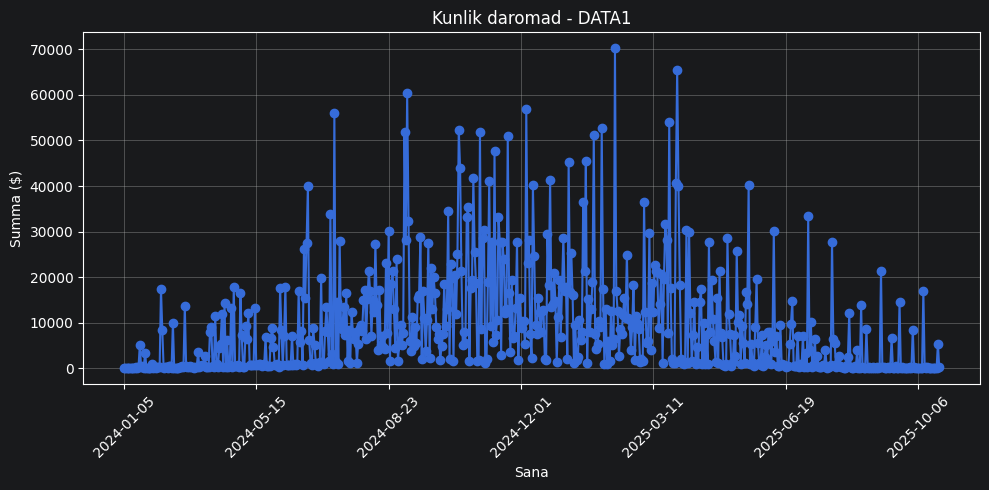

In [56]:
plt.figure(figsize=(10, 5))
daily_rev_plot = orders.groupby('date')['paid_price'].sum().sort_index()
daily_rev_plot.plot(kind='line', marker='o')
plt.title('Kunlik daromad - DATA1')
plt.xlabel('Sana')
plt.ylabel('Summa ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()